### Import das Classes

In [ ]:
import matplotlib.pyplot as plt

from src.ProblemaP1 import ProblemaP1
from src.ProblemGeneratorP1 import ProblemaP1Generator
from src.ProblemaP2 import ProblemaP2

### Redução do Sistema 
Comçamos com o sistema $M p = b$. Particionando o sistema entre nós livres $\mathcal{L}$ e nós fixos $\mathcal{F}$, temos:

$$
\begin{bmatrix}
M_{\mathcal{L}\mathcal{L}} & M_{\mathcal{L}\mathcal{F}} \\
M_{\mathcal{F}\mathcal{L}} & M_{\mathcal{F}\mathcal{F}}
\end{bmatrix}
\begin{bmatrix}
p_{\mathcal{L}} \\
p_{\mathcal{F}}
\end{bmatrix}
=
\begin{bmatrix}
b_{\mathcal{L}} \\
b_{\mathcal{F}}
\end{bmatrix}
$$

Da primeira linha do sistema, obtemos:

$$
M_{\mathcal{L}\mathcal{L}} p_{\mathcal{L}} + M_{\mathcal{L}\mathcal{F}} p_{\mathcal{F}} = b_{\mathcal{L}}
$$

Como $p_{\mathcal{F}}$ é conhecido, podemos isolar o termo das incógnitas:

$$
M_{\mathcal{L}\mathcal{L}} p_{\mathcal{L}} = b_{\mathcal{L}} - M_{\mathcal{L}\mathcal{F}} p_{\mathcal{F}}
$$

### Resolução

Assim, a solução para as pressões dos nós livres é:

$$
p_{\mathcal{L}} =
M_{\mathcal{L}\mathcal{L}}^{-1}
\left(
b_{\mathcal{L}} - M_{\mathcal{L}\mathcal{F}} p_{\mathcal{F}}
\right)
$$

Após resolver $p_{\mathcal{L}}$, o vetor completo de pressões $p$ é reconstruído combinando:

$$
p_i =
\begin{cases}
(p_{\mathcal{L}})_i, & \text{se } i \in \mathcal{L} \\
p_{\text{atm}}, & \text{se } i \in \mathcal{F}
\end{cases}
$$

### Problema Manual

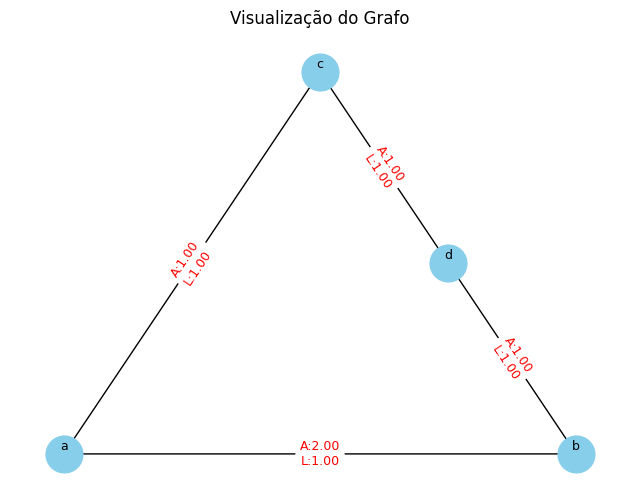

In [2]:
nodes = ['a', 'b', 'c', 'd']

edges = {
    'a': {'b': {"area": 2.0, "length": 1.0},
          'c': {"area": 1.0, "length": 1.0}},
    'b': {'d': {"area": 1.0, "length": 1.0}},
    'c': {'d': {"area": 1.0, "length": 1.0}},
    'd': {}
}

g = ProblemaP1(nodes, edges, mu=1.0, patm=0.0)
g.plot()

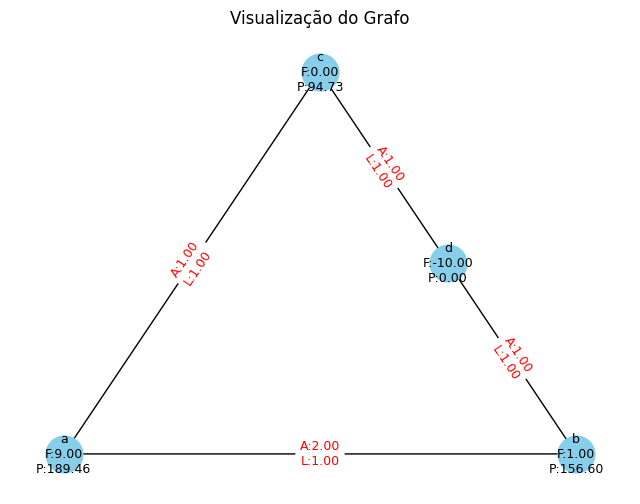

In [3]:
g.set_Q_ext({'a':9,'b':1,'c':0,'d':-10})
g.fit()
g.solve()

g.plot()

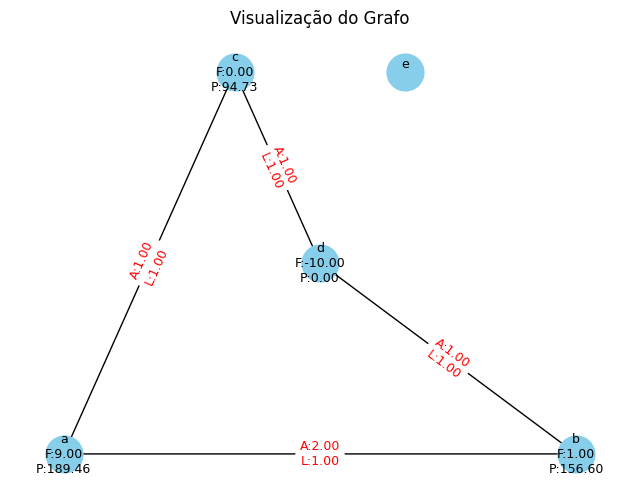

In [4]:
g.insert_node('e')
g.plot()

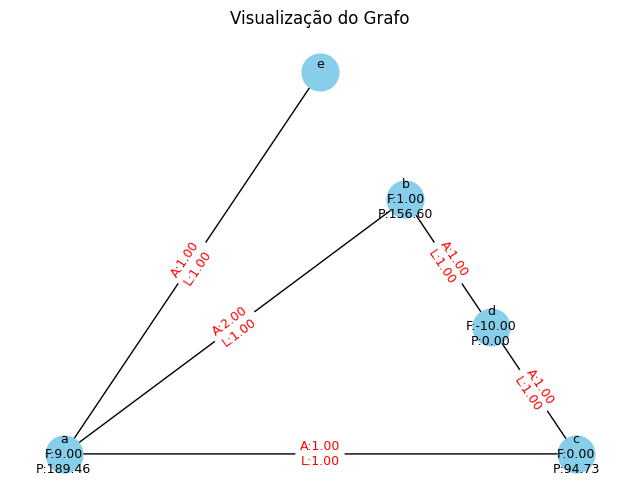

In [5]:
g.insert_edge('e', 'a', area=1.0, length=1.0)
g.plot()
plt.show()

In [6]:
g.set_Q_ext({'a':10,'b':0,'c':0,'d':-10, 'e':0})
g.fit().solve()
g.nodes


{'a': {'fluxo_externo': 10.0, 'pressao': 193.3287786824489},
 'b': {'fluxo_externo': 0.0, 'pressao': 154.6630229459591},
 'c': {'fluxo_externo': 0.0, 'pressao': 96.66438934122442},
 'd': {'fluxo_externo': -10.0, 'pressao': 0.0},
 'e': {'fluxo_externo': 0.0, 'pressao': 193.32877868244884}}

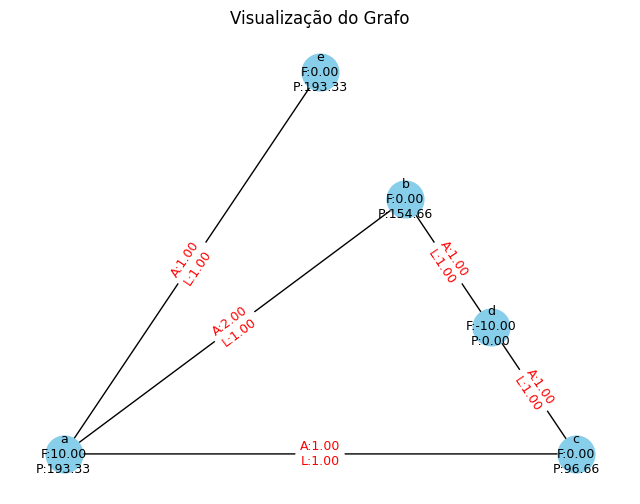

In [7]:
g.plot()

### Problema Gerado Aleatoriamente

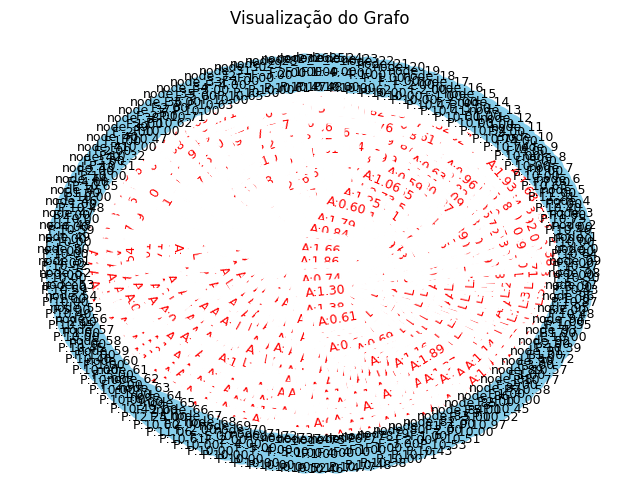

In [9]:
generator = ProblemaP1Generator(seed=42)
mu=.10
patm=10
prob = generator.generate(num_nodes=100, edge_prob=0.3, mu=mu, patm=patm)
prob.fit()
pressures = prob.solve()
prob.plot(show_edge_labels=True, layout='circular')